In [1]:
from utilities import init_bigquery_client
from google.cloud import bigquery
import os
import pandas as pd
import numpy as np

from plotnine import *

#init BigQuery client
bq = init_bigquery_client()

Using BigQuery credentials: etl-testing-478716-c0b6c2c512e0.json


## Bulk Reads

In [2]:
# Read from the 'events' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.events`
"""
events_df = bq.query(query).to_dataframe()

# Read from the 'userinvites' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.userinvites`
"""
userinvites_df = bq.query(query).to_dataframe()

# Read from the 'users' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.users`
"""
users_df = bq.query(query).to_dataframe()

/opt/miniconda3/envs/heyyall/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.


### Total Users

In [3]:
ios_users = users_df[~users_df['username'].isnull()]
web_users = users_df[users_df['username'].isnull()]

#print the number of users in each platform
print(f"Total number of users: {len(users_df)}")
print(f"Number of iOS users: {len(ios_users)}")
print(f"Number of web users: {len(web_users)}")

#current period
start_date = '2026-02-01'
end_date = '2026-02-15'

#Number of users in the added in the last 2 weeks
users_df['createdAt'] = pd.to_datetime(users_df['createdAt'])

ios_added_in_last_2_weeks = ios_users[(ios_users['createdAt'] >= (start_date)) & (ios_users['createdAt'] <= (end_date))]
web_added_in_last_2_weeks = web_users[(web_users['createdAt'] >= (start_date)) & (web_users['createdAt'] <= (end_date))]

print(f"{len(ios_added_in_last_2_weeks)} iOS users added in the last 2 weeks")
print(f"{len(web_added_in_last_2_weeks)} web users added in the last 2 weeks")

#Number of users added in prior period (2 weeks to 1 month ago)
prior_start_date = '2026-01-15'
prior_end_date = '2026-01-31'

ios_added_last_period = ios_users[(ios_users['createdAt'] >= (prior_start_date)) & (ios_users['createdAt'] <= (prior_end_date))]
web_added_last_period = web_users[(web_users['createdAt'] >= (prior_start_date)) & (web_users['createdAt'] <= (prior_end_date))]

print(f"{len(ios_added_last_period)} iOS users added in the last period (2 weeks to 1 month ago)")
print(f"{len(web_added_last_period)} web users added in the last period (2 weeks to 1 month ago)")

Total number of users: 688
Number of iOS users: 236
Number of web users: 452
45 iOS users added in the last 2 weeks
171 web users added in the last 2 weeks
5 iOS users added in the last period (2 weeks to 1 month ago)
47 web users added in the last period (2 weeks to 1 month ago)


In [5]:
import plotly.graph_objects as go

fig = go.Figure(go.Indicator(
    mode="number+delta",
    value=len(ios_added_in_last_2_weeks),
    delta={'reference': len(ios_added_last_period), 'relative': True, 'position': "left"},
    title={"text": "iOS Users Added (Last 2 Weeks)"},
    number={'font': {'size': 48}},
    domain={'x': [0, 1], 'y': [0, 1]}
))
fig.update_layout(paper_bgcolor="white", width=400, height=300)
fig.show()

In [6]:
fig = go.Figure(go.Indicator(
    mode="number+delta",
    value=len(web_added_in_last_2_weeks),
    delta={'reference': len(web_added_last_period), 'relative': True, 'position': "left", 'valueformat': ".0%"},
    title={"text": "Web Users Added (Last 2 Weeks)"},
    number={'font': {'size': 48}},
    domain={'x': [0, 1], 'y': [0, 1]}
))
fig.update_layout(paper_bgcolor="white", width=400, height=300)
fig.show()

In [4]:
import plotly.express as px

total_users = len(users_df)
ios_users_count = len(ios_users)
web_users_count = len(web_users)

# Prepare data for sunburst (starburst) chart
user_base_data = dict(
    labels=["Total Users", "iOS Users", "Web Users"],
    parents=["", "Total Users", "Total Users"],
    values=[total_users, ios_users_count, web_users_count]
)

fig = px.sunburst(
    user_base_data,
    names='labels',
    parents='parents',
    values='values',
    color='labels',
    color_discrete_map={
        'Total Users': "#0b67c3",
        'iOS Users': "#0fb717",
        'Web Users': "#fdb704"
    }
)
fig.update_traces(textinfo="label+value", textfont=dict(weight='bold'))
fig.update_layout(width = 500,
                  height = 500)
fig.show()

### Active event creators

In [7]:
# Group by date and count events
events_per_week = events_df[events_df['type']!='checkin'].resample('W', on='createdAt').size().reset_index(name='events_created')

#Calculate weekly uniquer planner counts
unique_planners_per_week = events_df.groupby(pd.Grouper(key='createdAt', freq='W'))['user_id'].nunique().reset_index(name='unique_planners')

# Filter to last 90 days
import datetime as datetime
days_90 = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=90)

events_per_week = events_per_week[events_per_week['createdAt'] >= days_90]
unique_planners_per_week = unique_planners_per_week[unique_planners_per_week['createdAt'] >= days_90]

In [8]:
#active event creators in last 14 days
active_event_creators_last_14_days = events_df[(events_df['createdAt'] >= (pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=14))) & (events_df['type']!='checkin')]['user_id'].nunique()
print(f"{active_event_creators_last_14_days} active event creators in the current period")

#active event creators in the period prior to the last 14 days
active_event_creators_prior_14_days = events_df[(events_df['createdAt'] < (pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=14)))
                                                & (events_df['createdAt'] >= (pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=28)))
                                                & (events_df['type']!='checkin')]['user_id'].nunique()
print(f"{active_event_creators_prior_14_days} active event creators in the period prior")

16 active event creators in the current period
8 active event creators in the period prior


In [9]:
fig = go.Figure(go.Indicator(
    mode="number+delta",
    value=active_event_creators_last_14_days,
    delta={'reference': active_event_creators_prior_14_days, 'relative': True, 'position': "left", 'valueformat': ".0%"},
    title={"text": "Active Event Creators (Last 2 Weeks)"},
    number={'font': {'size': 48}},
    domain={'x': [0, 1], 'y': [0, 1]}
))
fig.update_layout(paper_bgcolor="white", width=400, height=300)
fig.show()

### Repeat Creator Rate

In [10]:
# Sort by createdAt, then enumerate events per user
repeat_df = events_df.sort_values(['user_id', 'createdAt'])
repeat_df['event_number'] = repeat_df.groupby('user_id').cumcount() + 1

In [11]:
#getting total number of events planned by each user
repeat_df = repeat_df.drop_duplicates(subset=['user_id'], keep='last')

#print repeat event creator count 
solo_creator = len(repeat_df[repeat_df['event_number'] == 1])
repeat_creator = len(repeat_df[repeat_df['event_number'] > 1])
print(f"Solo event creators: {solo_creator}")
print(f"Repeat event creators: {repeat_creator}")
print(f"% repeat event creators: {repeat_creator / (solo_creator + repeat_creator) * 100:.2f}%")


Solo event creators: 14
Repeat event creators: 27
% repeat event creators: 65.85%


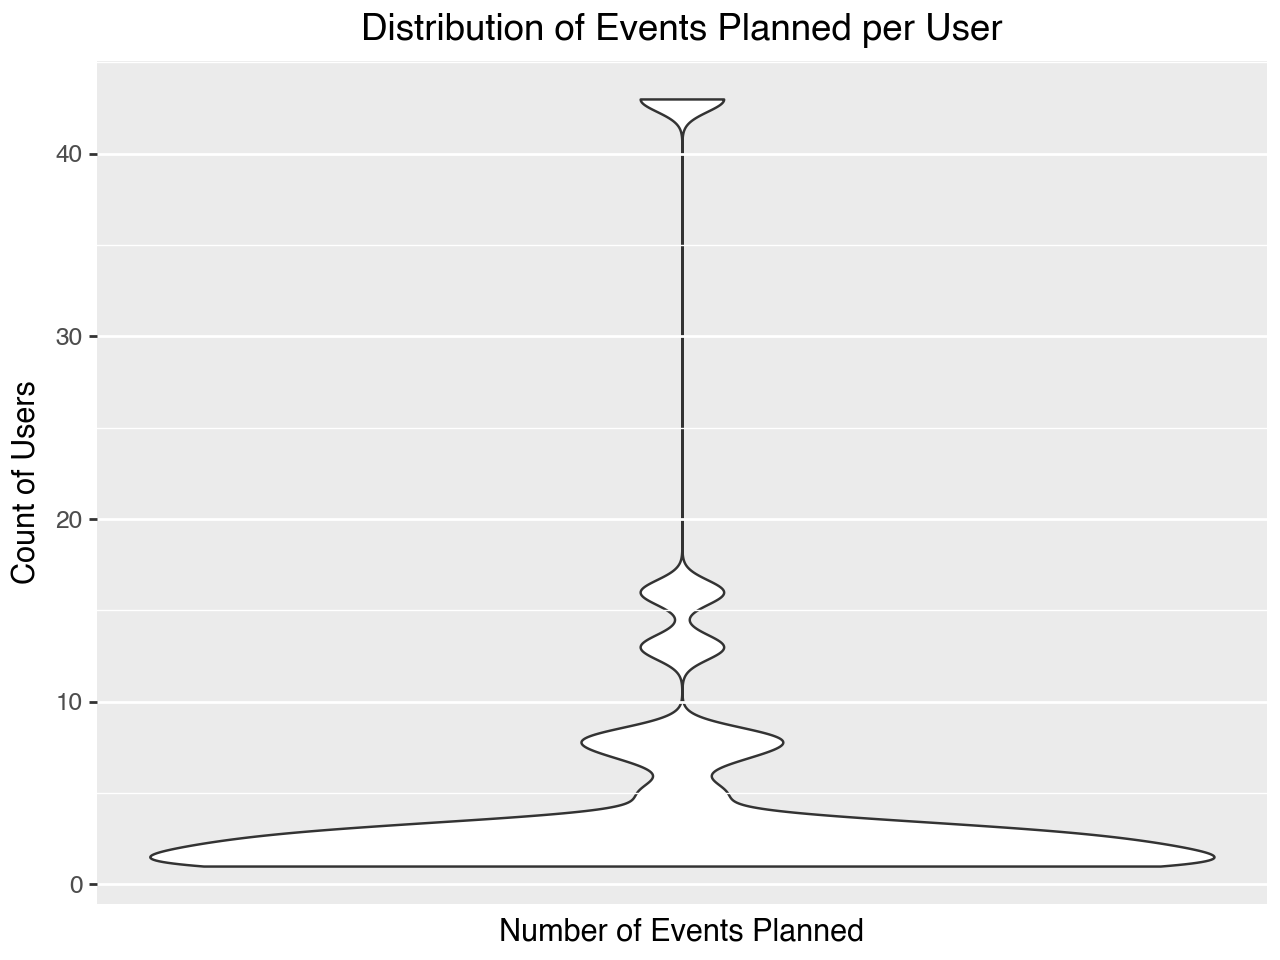

In [27]:

# Get distribution of events planned per user
repeat_histogram = (ggplot(repeat_df,
        aes(y='event_number')) +
    geom_violin() +
    scale_x_continuous(breaks=range(1, repeat_df['event_number'].max() + 1)) +
    labs(title='Distribution of Events Planned per User', x='Number of Events Planned', y='Count of Users')
)

repeat_histogram.show()

### Invite Conversion Rate

In [13]:
#business user invite conversion rate 
invites_extra_df = userinvites_df.merge(events_df.merge(users_df, on='user_id', how='left'), left_on='event_id', right_on='document_id', how='left')

In [16]:
# Prioritize 'accepted' status, otherwise keep first
invites_extra_df = invites_extra_df.sort_values(by=['status'], ascending=False)
invites_extra_df = invites_extra_df.drop_duplicates(subset=['event_id', 'user_id_x'], keep='first')

In [18]:
#total invites sent by business users
total_biz_invites = len(invites_extra_df[invites_extra_df['businessUser'] == True])
total_biz_invites_accepted = len(invites_extra_df[(invites_extra_df['businessUser'] == True)
                                                   & (invites_extra_df['status'] == 'accepted')])

print(total_biz_invites_accepted / total_biz_invites)

0.7425149700598802


In [19]:
#total invites sent by business users
total_nonbiz_invites = len(invites_extra_df[invites_extra_df['businessUser'] == False])
total_nonbiz_invites_accepted = len(invites_extra_df[(invites_extra_df['businessUser'] == False)
                                                   & (invites_extra_df['status'] == 'accepted')])

print(total_nonbiz_invites_accepted / total_nonbiz_invites)

0.4955357142857143
